# Block 3: Explainability, Evaluation, and Deployment
### Temporally Entangled Documents, DocEng '26 Tutorial

Block 2 left you with a model that does not lean on documentation speed.

The gap on what this actually leans on is what this block closes. Not with an approximation of an explanation, but with the actual arithmetic the model performed, decomposed feature by feature and then located in time. A contribution on its own tells you what the model weighed. It does not tell you whether that evidence was minutes old or most of a day old, and in a record where every stream runs on its own clock, the second question matters as much as the first.

Four things happen here. Exact attribution for one prediction. The same attribution spread across all four evidence streams in the record, which is what the word multimodal in this tutorial's title is supposed to mean. A reusable tool that flags a prediction resting on evidence that has gone stale. And then, to show case generalisability of the pipeline and interdisciplinarity of the concept, the same alignment code runs unchanged on a corpus that has nothing to do with medicine.

**Run it, watch it, break it, fix it.** Last time.

## Setup

In [61]:
!rm -rf doceng26-pulse-and-paper
!git clone -q https://github.com/lbutler2405/doceng26-pulse-and-paper.git
REPO_ROOT = "/content/doceng26-pulse-and-paper"
DATA_DIR = f"{REPO_ROOT}/data"

import sys
sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, brier_score_loss

import alignment as al
import models as m

TEAL, SEAFOAM, MINT, DARK, CORAL, AMBER = "#028090","#00A896","#02C39A","#0A2E36","#D96C6C","#E1A82D"

print("Ready.")

Ready.


In [62]:
naive_df, aware_df, meta_df = m.build_features(DATA_DIR)
y = meta_df["outcome"]
pipe, Xte, yte, proba = m.train_and_predict(aware_df, y)
patients, vitals, labs, notes, labels = m._load(DATA_DIR)
pred_times = m._prediction_times(patients, labels)

print(f"{len(naive_df)} patients, {aware_df.shape[1]} time-aware features, {len(Xte)} held out for "
      f"testing, {int(yte.sum())} of whom actually deteriorated.")
print("This is the exact same pipeline and split as Block 2's \"Meet the model\" section, trained")
print("here again fresh so this notebook runs on its own.")
print(f"Time-aware model AUROC on the held-out set: {roc_auc_score(yte, proba):.3f}")

75 patients, 12 time-aware features, 23 held out for testing, 13 of whom actually deteriorated.
This is the exact same pipeline and split as Block 2's "Meet the model" section, trained
here again fresh so this notebook runs on its own.
Time-aware model AUROC on the held-out set: 1.000


## The third panel: exact attribution

A logistic regression's coefficients are not a hint about what the model is doing, they are the computation method. For any one patient, `standardized_feature_value coefficient` is that feature's exact contribution to the predicted log-odds, and summing every feature's contribution plus the intercept reproduces the model's actual output, not an estimate of it. That's a different claim than most "explainability" methods get to make, and it is available because the model is transparent by construction, not because we added on an approximation after the fact.

In [63]:
def attribute(pipe, X_row):
    """Exact per-feature contribution to the predicted log-odds for one row."""
    imputed = pipe.named_steps["impute"].transform(X_row)
    scaled = pipe.named_steps["scale"].transform(imputed)
    coefs = pipe.named_steps["clf"].coef_[0]
    contrib = scaled[0] * coefs
    return pd.DataFrame({"feature": X_row.columns, "contribution": contrib}).sort_values(
        "contribution", key=abs, ascending=False)

In [64]:
patient_id = 90000041  # picked deliberately: you'll see exactly why two cells from now
report = attribute(pipe, Xte.loc[[patient_id]])
print(f"Patient {patient_id}, predicted probability: {proba[0]:.3f}")
print(report.to_string(index=False))

check = report.contribution.sum() + pipe.named_steps["clf"].intercept_[0]
implied_proba = 1 / (1 + np.exp(-check))
print(f"\nsum of contributions + intercept = {check:.4f}  ->  implied probability = {implied_proba:.4f}")
print("(matches the model's own predicted probability above, exactly, not approximately)")

Patient 90000041, predicted probability: 0.981
            feature  contribution
     heartrate_last      1.076016
         o2sat_last      0.782546
      lactate_slope      0.751321
           sbp_last      0.515218
       lactate_last     -0.287461
          sbp_slope      0.179260
        o2sat_slope      0.147141
vitals_completeness     -0.112312
      troponin_last     -0.074871
    heartrate_slope      0.070951
  labs_completeness     -0.023140
     troponin_slope      0.006146

sum of contributions + intercept = 3.5193  ->  implied probability = 0.9712
(matches the model's own predicted probability above, exactly, not approximately)


## Not just what: when

That table tells you *what* mattered. It says nothing about *when* the evidence behind each number actually arrived, and that is exactly the gap this whole tutorial has been about. A feature can dominate a prediction and still be built on hours-old evidence, indistinguishable in the table above from a feature built on evidence from thirty seconds ago. Let us fix that, by locating each feature's underlying evidence on the timeline it actually came from.

In [65]:
FEATURE_SOURCE = {
    "heartrate_last": ("vitals", "charttime"), "heartrate_slope": ("vitals", "charttime"),
    "o2sat_last": ("vitals", "charttime"), "o2sat_slope": ("vitals", "charttime"),
    "sbp_last": ("vitals", "charttime"), "sbp_slope": ("vitals", "charttime"),
    "lactate_last": ("lactate", "storetime"), "lactate_slope": ("lactate", "storetime"),
    "troponin_last": ("troponin", "storetime"), "troponin_slope": ("troponin", "storetime"),
}

def last_evidence_time(df, timecol, pred_time, lookback_hours=48):
    window = al.naive_window(df, timecol, pred_time, lookback_hours)
    return window[timecol].iloc[-1] if len(window) else None

def time_located_report(sid, pred_time):
    report = attribute(pipe, aware_df.loc[[sid]])
    pv = vitals[vitals.subject_id == sid]
    pl = labs[labs.subject_id == sid]
    source_map = {"vitals": pv, "lactate": pl[pl.label == "Lactate"], "troponin": pl[pl.label == "Troponin"]}
    ages = []
    for f in report.feature:
        if f not in FEATURE_SOURCE:
            ages.append(np.nan)
            continue
        src, timecol = FEATURE_SOURCE[f]
        t = last_evidence_time(source_map[src], timecol, pred_time)
        ages.append((pred_time - t).total_seconds() / 3600 if t is not None else np.nan)
    report = report.copy()
    report["evidence_age_h"] = ages
    return report

In [66]:
report = time_located_report(patient_id, pred_times[patient_id])
print(report.to_string(index=False))

            feature  contribution  evidence_age_h
     heartrate_last      1.076016        0.016667
         o2sat_last      0.782546        0.016667
      lactate_slope      0.751321        9.500000
           sbp_last      0.515218        0.016667
       lactate_last     -0.287461        9.500000
          sbp_slope      0.179260        0.016667
        o2sat_slope      0.147141        0.016667
vitals_completeness     -0.112312             NaN
      troponin_last     -0.074871       10.450000
    heartrate_slope      0.070951        0.016667
  labs_completeness     -0.023140             NaN
     troponin_slope      0.006146       10.450000


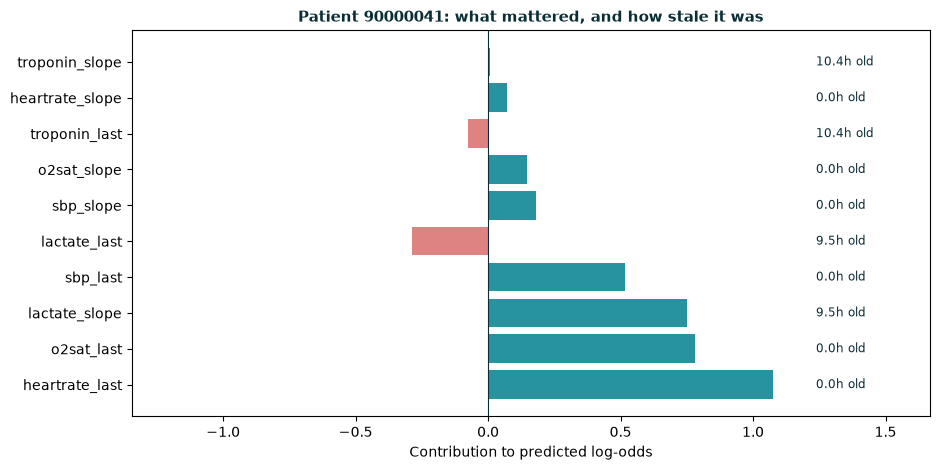

In [67]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
plot_df = report.dropna(subset=["evidence_age_h"])
colors = [CORAL if c < 0 else TEAL for c in plot_df.contribution]
ax.barh(plot_df.feature, plot_df.contribution, color=colors, alpha=0.85)
xmax = plot_df.contribution.abs().max()
label_x = xmax * 1.15
for y_pos, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(label_x, y_pos, f"{row.evidence_age_h:.1f}h old", va="center", ha="left", fontsize=8.5, color=DARK)
ax.axvline(0, color=DARK, linewidth=0.8)
ax.set_xlim(-xmax * 1.25, xmax * 1.55)
ax.set_xlabel("Contribution to predicted log-odds")
ax.set_title(f"Patient {patient_id}: what mattered, and how stale it was", fontsize=11, color=DARK, fontweight="bold")
fig.tight_layout()
plt.show()

This figure does not show attribution or a timeline alone, but both at once, for one real prediction. This is "time-aware explainability," and it is built from two functions you we have previously used, i.e. the same `attribute()` logic Block 2's `feature_importance()` used, and the same `naive_window()` you have been using since Step 3 of Block 1.

## Making it actually multimodal

Look again at the feature list in that chart. It is all vitals and labs. That is two evidence streams, but for *Multimodal AI for ICU Records*, there two might not be enough. The taxonomy from Block 0 had more in it than that, and the attribution above quietly ignores half of it.

So let us add the two that are missing. Diagnostic studies, meaning the ECG and echo reports  parsed in Block 1. And text, meaning what the clinical notes actually say.

That second one needs a bit more care. Block 2 spent a long time removing note features from this model. Block 2 removed note *timing*, how many notes exist, how recently one was charted, because that is a proxy for how fast a ward does its paperwork. It never removed note *content*. A drug named in a note is a clinical fact about the patient. When the note was typed is a fact about the hospital. The first belongs in a model. The second is the shortcut.

In [68]:
ecg_events = pd.read_csv(f"{DATA_DIR}/synthetic_ecg_events.csv", parse_dates=["ecg_time", "report_time"])
echo_events = pd.read_csv(f"{DATA_DIR}/synthetic_echo_events.csv", parse_dates=["echo_time", "report_time"])
med_labels = pd.read_csv(f"{DATA_DIR}/synthetic_medication_labels.csv")

rows = []
for sid in aware_df.index:
    pt = pred_times[sid]
    r = {"subject_id": sid}

    # Diagnostic studies. Only studies REPORTED by prediction time, a study that has
    # been performed but not yet read is not evidence anyone could have acted on.
    pe = ecg_events[(ecg_events.subject_id == sid) & (ecg_events.report_time <= pt)].sort_values("report_time")
    r["ecg_rr_interval"] = pe.rr_interval.iloc[-1] if len(pe) else np.nan
    r["ecg_qrs_axis"] = pe.qrs_axis.iloc[-1] if len(pe) else np.nan
    pc = echo_events[(echo_events.subject_id == sid) & (echo_events.report_time <= pt)].sort_values("report_time")
    r["echo_lvef"] = pc.lvef_percent.iloc[-1] if len(pc) else np.nan

    # Text. What the notes SAY, from the character-span medication labels you met in
    # Block 1. Only notes actually charted by prediction time, and no counts of notes
    # or gaps between them anywhere, that was the Block 2 shortcut.
    charted = notes[(notes.subject_id == sid) & (notes.storetime <= pt)].note_id.unique()
    pm = med_labels[(med_labels.subject_id == sid) & (med_labels.note_id.isin(charted))]
    drugs = pm[pm.Annotation == "MEDICATION"].Text.str.lower()
    r["text_n_distinct_meds"] = drugs.nunique()
    r["text_has_diuretic"] = int(drugs.isin(["furosemide", "lasix"]).any())
    r["text_has_anticoag"] = int(drugs.isin(["heparin", "apixaban", "eliquis"]).any())
    rows.append(r)

extra_modalities = pd.DataFrame(rows).set_index("subject_id")
mm_df = aware_df.join(extra_modalities)

print(f"{aware_df.shape[1]} features before, {mm_df.shape[1]} after adding two more modalities.")
print()
print("How many patients actually have each new feature:")
for c in extra_modalities.columns:
    print(f"  {c:24s} {extra_modalities[c].notna().mean():.0%}")

12 features before, 18 after adding two more modalities.

How many patients actually have each new feature:
  ecg_rr_interval          61%
  ecg_qrs_axis             61%
  echo_lvef                23%
  text_n_distinct_meds     100%
  text_has_diuretic        100%
  text_has_anticoag        100%


Notice the coverage column. ECG reaches about six patients in ten, echo closer to two. That is not a data problem we should tidy away, but it is how diagnostic studies work. Not every patient gets an echo, and the ones who do get it because somebody ordered it. The imputer handles the gap, and `vitals_completeness` and `labs_completeness` are already in the model precisely because absence carries information.

Now train it and see whether four modalities beat two.

In [69]:
pipe_mm, Xte_mm, yte_mm, proba_mm = m.train_and_predict(mm_df, y)

print(f"Two modalities  (vitals + labs)             AUROC {roc_auc_score(yte, proba):.3f}   {aware_df.shape[1]} features")
print(f"Four modalities (+ diagnostic studies, text) AUROC {roc_auc_score(yte_mm, proba_mm):.3f}   {mm_df.shape[1]} features")
print()
print("No improvement, and that is the honest result on this corpus. Physiology already")
print("separates these patients cleanly, so there is nothing left for another modality to add.")
print("The reason to go multimodal here is not accuracy. It is that a clinician asking what")
print("the model used deserves an answer that covers every stream in the record, not the two")
print("that happened to be easiest to featurise.")

Two modalities  (vitals + labs)             AUROC 1.000   12 features
Four modalities (+ diagnostic studies, text) AUROC 1.000   18 features

No improvement, and that is the honest result on this corpus. Physiology already
separates these patients cleanly, so there is nothing left for another modality to add.
The reason to go multimodal here is not accuracy. It is that a clinician asking what
the model used deserves an answer that covers every stream in the record, not the two
that happened to be easiest to featurise.


### Cross-modal, time-located attribution

Now the version the tutorial has been promising since Block 0. Group every feature by which evidence stream it came from, sum the contributions inside each group, and put that next to how old each stream's newest evidence actually was at prediction time.

Two questions, one figure. What did the model lean on, and how fresh was it.

In [70]:
MODALITY = {}
for c in mm_df.columns:
    if c.startswith(("heartrate", "o2sat", "sbp", "vitals_")):
        MODALITY[c] = "Biosignal (vitals)"
    elif c.startswith(("lactate", "troponin", "labs_")):
        MODALITY[c] = "Tabular (labs)"
    elif c.startswith(("ecg_", "echo_")):
        MODALITY[c] = "Diagnostic studies"
    elif c.startswith("text_"):
        MODALITY[c] = "Text (note content)"

def modality_report(sid, pred_time):
    """Contribution summed within each modality, next to the age of that
    modality's newest evidence at prediction time."""
    rep = attribute(pipe_mm, mm_df.loc[[sid]])
    rep["modality"] = rep.feature.map(MODALITY)
    contrib = rep.groupby("modality").contribution.apply(lambda s: s.abs().sum())

    age = lambda t: (pred_time - t).total_seconds() / 3600
    pv = al.naive_window(vitals[vitals.subject_id == sid], "charttime", pred_time, 48)
    pl = al.naive_window(labs[labs.subject_id == sid], "storetime", pred_time, 48)
    pe = ecg_events[(ecg_events.subject_id == sid) & (ecg_events.report_time <= pred_time)]
    pc = echo_events[(echo_events.subject_id == sid) & (echo_events.report_time <= pred_time)]
    pn = notes[(notes.subject_id == sid) & (notes.storetime <= pred_time)]
    study_times = list(pe.report_time) + list(pc.report_time)

    ages = {
        "Biosignal (vitals)": age(pv.charttime.iloc[-1]) if len(pv) else np.nan,
        "Tabular (labs)": age(pl.storetime.iloc[-1]) if len(pl) else np.nan,
        "Diagnostic studies": age(max(study_times)) if study_times else np.nan,
        "Text (note content)": age(pn.storetime.max()) if len(pn) else np.nan,
    }
    out = pd.DataFrame({"contribution": contrib, "evidence_age_h": pd.Series(ages)})
    return out.sort_values("contribution", ascending=False)

mod_rep = modality_report(patient_id, pred_times[patient_id])
print(f"Patient {patient_id}, across all four modalities:")
print(mod_rep.round(2).to_string())

Patient 90000041, across all four modalities:
                     contribution  evidence_age_h
Biosignal (vitals)           2.80            0.02
Tabular (labs)               1.32            9.50
Diagnostic studies           0.10           20.07
Text (note content)          0.04            1.97


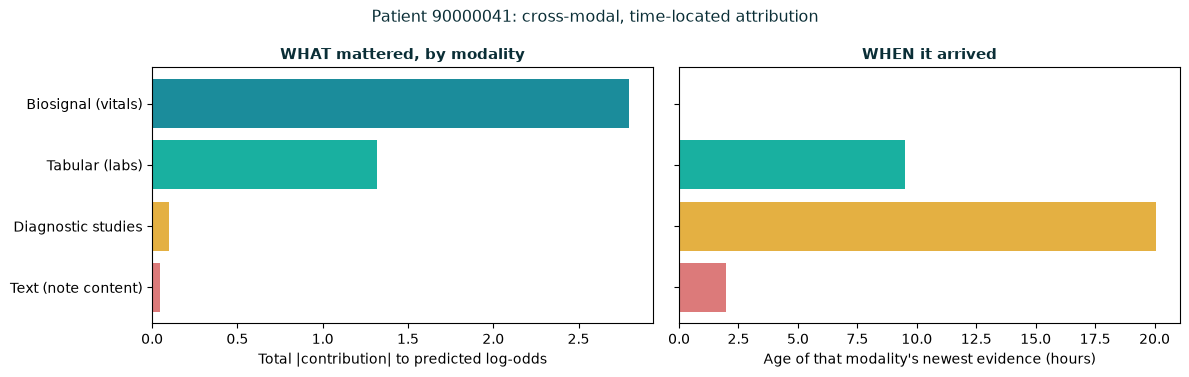

In [71]:
plot_df = mod_rep.dropna(subset=["evidence_age_h"])
order = list(plot_df.index)
colours = [TEAL, SEAFOAM, AMBER, CORAL][:len(order)]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

ax = axes[0]
ax.barh(order, plot_df.contribution, color=colours, alpha=0.9)
ax.invert_yaxis()
ax.set_xlabel("Total |contribution| to predicted log-odds")
ax.set_title("WHAT mattered, by modality", fontsize=10.5, color=DARK, fontweight="bold")

ax = axes[1]
ax.barh(order, plot_df.evidence_age_h, color=colours, alpha=0.9)
ax.invert_yaxis()
ax.set_yticklabels([])
ax.set_xlabel("Age of that modality's newest evidence (hours)")
ax.set_title("WHEN it arrived", fontsize=10.5, color=DARK, fontweight="bold")

fig.suptitle(f"Patient {patient_id}: cross-modal, time-located attribution", fontsize=11.5, color=DARK)
fig.tight_layout()
plt.show()

Read the two panels together, because either one alone is misleading.

The left panel says vitals dominate and the diagnostic studies barely register. Read alone, that sounds like the ECG was not worth having. The right panel explains why. The vitals are current to the minute. The ECG report is the oldest evidence in the record by a wide margin. The model is not ignoring the ECG because ECGs are uninformative, it is leaning on the stream that had something recent to say.

That distinction is the whole reason to locate evidence in time as well as in modality. "The model used the vitals" is a fact about the model. "The model used the vitals because they were the only stream still current when the prediction was made" is a fact about the record, and it is the one a clinician can act on. If the ECG is genuinely the more informative study for this patient, the fix is not a better model. It is getting the report read sooner.

### Is each modality earning its place?

The chart above shows what the model leaned on for one patient. It does not tell you whether a modality is worth collecting at all. For that, drop each one in turn and retrain.

This is the standard multimodal question and it is worth asking honestly, because the answer here is not flattering to three of the four streams.

In [72]:
ablation = []
_, _, yte_all, proba_all = m.train_and_predict(mm_df, y)
ablation.append(("All four modalities", roc_auc_score(yte_all, proba_all), brier_score_loss(yte_all, proba_all)))

for mod in ["Biosignal (vitals)", "Tabular (labs)", "Diagnostic studies", "Text (note content)"]:
    keep = [col for col in mm_df.columns if MODALITY[col] != mod]
    _, _, yt, pr = m.train_and_predict(mm_df[keep], y)
    ablation.append((f"without {mod}", roc_auc_score(yt, pr), brier_score_loss(yt, pr)))

abl = pd.DataFrame(ablation, columns=["feature set", "AUROC", "Brier"]).set_index("feature set")
abl.round(4)

,AUROC,Brier
feature set,,
All four modalities,1.0,0.0008
without Biosignal (vitals),0.8,0.1719
without Tabular (labs),1.0,0.0009
without Diagnostic studies,1.0,0.0007
without Text (note content),1.0,0.0010


Read the AUROC column first. Three of the four ablations leave it at 1.000. By that metric you could throw away the labs, the diagnostic studies, and the text, and conclude you had lost nothing.

Now read the Brier column. Removing the vitals moves it from roughly 0.0008 to 0.17, which is two orders of magnitude worse. Removing any other modality barely moves it at all.

Both columns are telling the truth. On this corpus the deterioration signal lives almost entirely in the vitals, which we already know from the separability chart further down. What the two columns disagree about is whether AUROC is capable of showing you that, and it is not. This is the same lesson as Block 2, arriving from a different direction: the headline metric is the last thing that will tell you a modality is carrying the model.

Worth being clear about what this ablation does and does not say. It says these three modalities add little *on this synthetic corpus*, where I built the deterioration signal into the vitals. It does not say ECGs and clinical notes are uninformative in general, and if it did, that would be a finding about my generator rather than about medicine.

### Not every patient has every modality

One more thing that only shows up once a pipeline is multimodal. In the ICU, which modalities exist is itself a clinical decision. Not every patient gets an echo, and the ones who do get it because somebody ordered it.

In [73]:
present = pd.DataFrame({
    "Biosignal (vitals)": True,
    "Tabular (labs)": True,
    "Diagnostic studies": mm_df[["ecg_rr_interval", "echo_lvef"]].notna().any(axis=1),
    "Text (note content)": mm_df["text_n_distinct_meds"] > 0,
}, index=mm_df.index)

counts = present.sum(axis=1).value_counts().sort_index()
print("How many of the four modalities each patient actually has:")
for n_mod, n_pat in counts.items():
    print(f"  {n_mod} modalities: {n_pat} patients")
print()
print("Per modality, share of patients who have it at all:")
for col in present.columns:
    print(f"  {col:22s} {present[col].mean():.0%}")

How many of the four modalities each patient actually has:
  2 modalities: 14 patients
  3 modalities: 29 patients
  4 modalities: 32 patients

Per modality, share of patients who have it at all:
  Biosignal (vitals)     100%
  Tabular (labs)         100%
  Diagnostic studies     68%
  Text (note content)    56%


So a fifth of the corpus reaches this model with only two of the four streams present, and barely two in five have all four.

That is not missing data in the sense of a broken export. It is a fact about the patient's care. The imputer fills those gaps with a corpus median, which is a reasonable default and also a small lie: it tells the model this patient had an average ECG, when the truth is that nobody ordered one. `vitals_completeness` and `labs_completeness` exist in the feature set precisely because absence is information, and a genuinely multimodal pipeline would carry that idea across every stream rather than the two it started with.

A note on what this pipeline is doing structurally. Concatenating features from four streams into one table and fitting a single model is early fusion, the simplest of the standard options. Late fusion would train a model per modality and combine their predictions, which handles missing modalities more gracefully and lets each stream have its own temporal treatment. Intermediate fusion learns a joint representation. I chose early fusion because it keeps the attribution exact and readable, which is the whole point of Block 3. The trade-off is real, and it is the one the ablation above is quietly showing you.

## A temporal-inconsistency audit tool

From what we have seen, `lactate_slope` carries real weight in patient 90000041's prediction and it rests on evidence nine and a half hours old, sitting next to vitals that are essentially real-time. That was a human noticing a pattern in a chart. The artefact this tutorial calls a temporal inconsistency audit tool is making a machine notice the same pattern automatically, across every prediction, without anyone having to look first.

Score every feature by `|contribution| x evidence_age_hours`, flag whatever clears a threshold, and you have a report a reviewer can act on. Running it across all four modalities means extending the evidence-age lookup to cover diagnostic studies and text, which are the streams most likely to be stale.

In [74]:
# Where each feature's evidence comes from, now covering all four modalities.
FEATURE_SOURCE_MM = {}
for col in mm_df.columns:
    if col.startswith(("heartrate", "o2sat", "sbp")):
        FEATURE_SOURCE_MM[col] = ("vitals", "charttime")
    elif col.startswith("lactate"):
        FEATURE_SOURCE_MM[col] = ("lactate", "storetime")
    elif col.startswith("troponin"):
        FEATURE_SOURCE_MM[col] = ("troponin", "storetime")
    elif col.startswith("ecg_"):
        FEATURE_SOURCE_MM[col] = ("ecg", "report_time")
    elif col.startswith("echo_"):
        FEATURE_SOURCE_MM[col] = ("echo", "report_time")
    elif col.startswith("text_"):
        FEATURE_SOURCE_MM[col] = ("text", "storetime")
    # the two *_completeness features describe the record rather than sitting in it,
    # so they have no evidence age and are left out on purpose

display(FEATURE_SOURCE_MM)

{'heartrate_last': ('vitals', 'charttime'),
 'heartrate_slope': ('vitals', 'charttime'),
 'o2sat_last': ('vitals', 'charttime'),
 'o2sat_slope': ('vitals', 'charttime'),
 'sbp_last': ('vitals', 'charttime'),
 'sbp_slope': ('vitals', 'charttime'),
 'lactate_last': ('lactate', 'storetime'),
 'lactate_slope': ('lactate', 'storetime'),
 'troponin_last': ('troponin', 'storetime'),
 'troponin_slope': ('troponin', 'storetime'),
 'ecg_rr_interval': ('ecg', 'report_time'),
 'ecg_qrs_axis': ('ecg', 'report_time'),
 'echo_lvef': ('echo', 'report_time'),
 'text_n_distinct_meds': ('text', 'storetime'),
 'text_has_diuretic': ('text', 'storetime'),
 'text_has_anticoag': ('text', 'storetime')}

In [75]:
def time_located_report_mm(sid, pred_time):
    """Per-feature contribution and evidence age, across all four modalities."""
    report = attribute(pipe_mm, mm_df.loc[[sid]])
    pl = labs[labs.subject_id == sid]
    sources = {
        "vitals":   (vitals[vitals.subject_id == sid], "charttime", True),
        "lactate":  (pl[pl.label == "Lactate"], "storetime", True),
        "troponin": (pl[pl.label == "Troponin"], "storetime", True),
        "ecg":      (ecg_events[(ecg_events.subject_id == sid) & (ecg_events.report_time <= pred_time)], "report_time", False),
        "echo":     (echo_events[(echo_events.subject_id == sid) & (echo_events.report_time <= pred_time)], "report_time", False),
        "text":     (notes[(notes.subject_id == sid) & (notes.storetime <= pred_time)], "storetime", False),
    }
    ages = []
    for f in report.feature:
        if f not in FEATURE_SOURCE_MM:
            ages.append(np.nan)
            continue
        name, timecol = FEATURE_SOURCE_MM[f]
        df, tc, windowed = sources[name]
        if windowed:
            w = al.naive_window(df, tc, pred_time, 48)
            t = w[tc].iloc[-1] if len(w) else None
        else:
            t = df[tc].max() if len(df) else None
        ages.append((pred_time - t).total_seconds() / 3600 if t is not None else np.nan)
    report["evidence_age_h"] = ages
    return report

def audit_temporal_consistency(sid, pred_time, staleness_threshold=3.0):
    """Flags any feature whose contribution is meaningful AND whose evidence is
    older than that much confidence deserves."""
    report = time_located_report_mm(sid, pred_time)
    report["staleness_score"] = report.contribution.abs() * report.evidence_age_h.fillna(0)
    report["flag"] = report.staleness_score > staleness_threshold
    report["modality"] = report.feature.map(MODALITY)
    return report.sort_values("staleness_score", ascending=False)

print("The patient we decided to review, now audited across all four modalities:")
print(audit_temporal_consistency(patient_id, pred_times[patient_id])
      .head(6)[["feature", "modality", "contribution", "evidence_age_h", "staleness_score", "flag"]]
      .to_string(index=False))

The patient we decided to review, now audited across all four modalities:
        feature           modality  contribution  evidence_age_h  staleness_score  flag
  lactate_slope     Tabular (labs)      0.874912        9.500000         8.311660  True
   lactate_last     Tabular (labs)     -0.330456        9.500000         3.139327  True
   ecg_qrs_axis Diagnostic studies     -0.060288       20.066667         1.209784 False
  troponin_last     Tabular (labs)     -0.082019       10.450000         0.857095 False
ecg_rr_interval Diagnostic studies     -0.022634       20.066667         0.454182 False
 troponin_slope     Tabular (labs)      0.008697       10.450000         0.090882 False


In [76]:
all_points = []
for sid in Xte_mm.index:
    rep = audit_temporal_consistency(sid, pred_times[sid])
    for _, row in rep.dropna(subset=["evidence_age_h"]).iterrows():
        all_points.append((sid, row.feature, row.modality, abs(row.contribution),
                           row.evidence_age_h, row.staleness_score, row.flag))

pts = pd.DataFrame(all_points, columns=["subject_id", "feature", "modality",
                                         "abs_contribution", "evidence_age_h",
                                         "staleness_score", "flagged"])

print(f"{len(pts)} (feature, patient) pairs checked across the held-out set, {pts.flagged.sum()} flagged.")
print()
print("The five most temporally inconsistent, anywhere in the held-out set:")
print(pts.sort_values("staleness_score", ascending=False).head(5)
      [["subject_id", "feature", "modality", "evidence_age_h", "staleness_score"]]
      .to_string(index=False))
print()
print("Which modality the flags come from:")
print(pts[pts.flagged].modality.value_counts().to_string())

306 (feature, patient) pairs checked across the held-out set, 14 flagged.

The five most temporally inconsistent, anywhere in the held-out set:
 subject_id           feature            modality  evidence_age_h  staleness_score
   90000052 text_has_diuretic Text (note content)       30.986316        24.769889
   90000068   ecg_rr_interval  Diagnostic studies       41.683333        19.016415
   90000027   ecg_rr_interval  Diagnostic studies       23.799845        10.137987
   90000073      ecg_qrs_axis  Diagnostic studies       35.402170         9.900806
   90000041     lactate_slope      Tabular (labs)        9.500000         8.311660

Which modality the flags come from:
modality
Diagnostic studies     8
Tabular (labs)         5
Text (note content)    1


Patient 90000041, the one I picked out by eye, is genuinely flagged. It is also no longer the worst case in the set, and what displaced it is the interesting part.

The top flag is a *text* feature, `text_has_diuretic`, carrying real weight on a note charted about thirty-one hours before the prediction. Most of the rest are *ECG* features. Both of those streams were invisible to the audit twenty minutes ago, because the model only had vitals and labs in it. Adding two modalities did not improve accuracy at all, as the ablation showed. It roughly multiplied what the audit could see.

That is the argument for multimodality that survives the ablation result. The extra streams were not worth much for prediction on this corpus. They were worth a great deal for knowing what the prediction was resting on.

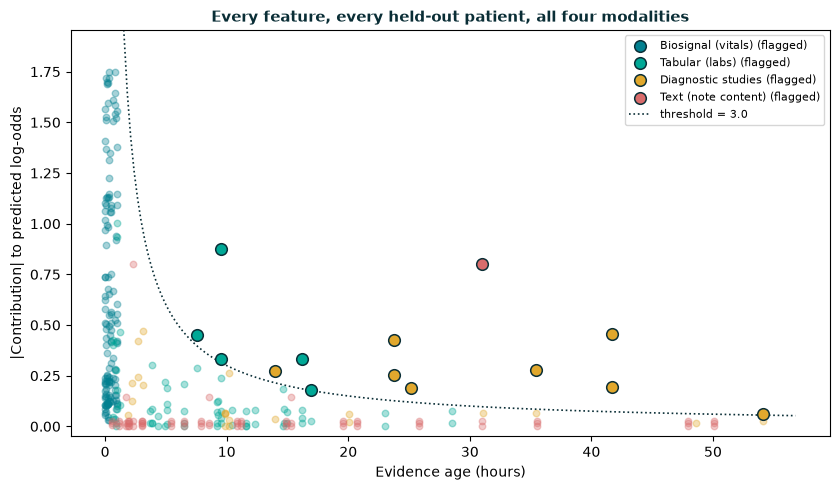

In [77]:
fig, ax = plt.subplots(figsize=(8.5, 5))

palette = {"Biosignal (vitals)": TEAL, "Tabular (labs)": SEAFOAM,
           "Diagnostic studies": AMBER, "Text (note content)": CORAL}

for mod, colour in palette.items():
    sub = pts[(pts.modality == mod) & (~pts.flagged)]
    ax.scatter(sub.evidence_age_h, sub.abs_contribution, color=colour, alpha=0.35, s=22)
for mod, colour in palette.items():
    sub = pts[(pts.modality == mod) & (pts.flagged)]
    ax.scatter(sub.evidence_age_h, sub.abs_contribution, color=colour, s=70,
               edgecolors=DARK, linewidth=1.1, zorder=3, label=f"{mod} (flagged)")

h = np.linspace(0.4, pts.evidence_age_h.max() * 1.05, 200)
ax.plot(h, 3.0 / h, color=DARK, linestyle=":", linewidth=1.2, label="threshold = 3.0")

ax.set_ylim(-0.05, pts.abs_contribution.max() * 1.12)
ax.set_xlabel("Evidence age (hours)")
ax.set_ylabel("|Contribution| to predicted log-odds")
ax.set_title("Every feature, every held-out patient, all four modalities",
             fontsize=11, color=DARK, fontweight="bold")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

Read the colours. The teal points, i.e. the vitals, are clustered at the left edge because a bedside monitor never provide stale data. Everything that drifts right is a lab, a diagnostic study, or a note, and every flagged point sits above the threshold curve rather than merely far along the x-axis. Old evidence on its own is fine. Old evidence the model is leaning on is the thing worth a second look.

In deployment this is the report a reviewer sees before the prediction ships. Not because the model is wrong, it may well be right, but because a prediction resting on a thirty-one hour old note deserves someone asking whether anything has changed since.

## Evaluation beyond AUROC

Almost every AUROC in this tutorial has been 1.000, and if you have been wondering whether that is suspicious, it should be. Let us seeexactly why it happens, because the reason matters more than the number.

In [78]:
hr = aware_df["heartrate_last"]
solo_auroc = max(roc_auc_score(y, hr), 1 - roc_auc_score(y, hr))

print(f"AUROC of heartrate_last on its own, no model involved: {solo_auroc:.3f}")
print()
print(f"  Deteriorated  ({(y==1).sum()} patients): {hr[y==1].min():.0f} to {hr[y==1].max():.0f} bpm")
print(f"  Did not       ({(y==0).sum()} patients): {hr[y==0].min():.0f} to {hr[y==0].max():.0f} bpm")
print(f"  Gap between them: {hr[y==1].min() - hr[y==0].max():.1f} bpm, with no overlap at all")
print()
print(f'A single rule, "heart rate above {hr[y==0].max():.0f}", classifies all {len(y)} patients correctly.')

AUROC of heartrate_last on its own, no model involved: 1.000

  Deteriorated  (41 patients): 107 to 129 bpm
  Did not       (34 patients): 70 to 95 bpm
  Gap between them: 12.2 bpm, with no overlap at all

A single rule, "heart rate above 95", classifies all 75 patients correctly.


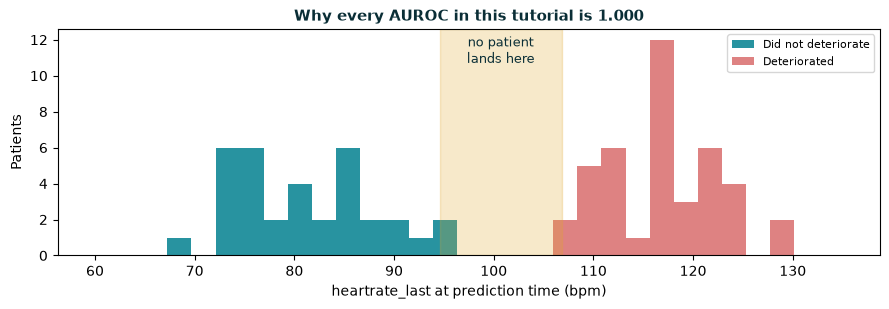

In [79]:
fig, ax = plt.subplots(figsize=(9, 3.2))
bins = np.linspace(60, 135, 32)
ax.hist(hr[y == 0], bins=bins, color=TEAL, alpha=0.85, label="Did not deteriorate")
ax.hist(hr[y == 1], bins=bins, color=CORAL, alpha=0.85, label="Deteriorated")
ax.axvspan(hr[y == 0].max(), hr[y == 1].min(), color=AMBER, alpha=0.25)
ax.text((hr[y == 0].max() + hr[y == 1].min()) / 2, ax.get_ylim()[1] * 0.85,
        "no patient\nlands here", ha="center", fontsize=9, color=DARK)
ax.set_xlabel("heartrate_last at prediction time (bpm)")
ax.set_ylabel("Patients")
ax.set_title("Why every AUROC in this tutorial is 1.000", fontsize=11, color=DARK, fontweight="bold")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

This is a property of the generator, not of the models. `synthetic_generator.py` applies a deterioration shift of +38 bpm against a baseline standard deviation of 6, which is a shift of more than six standard deviations. Two groups separated that far cannot overlap. A real deteriorating patient might run fifteen to twenty-five bpm above their own baseline, against much larger variation between patients, and the distributions would sit on top of each other.

I am showing you this rather than quietly letting the 1.000 stand, for three reasons.

The classification task in this corpus was solved before any model existed, so no AUROC in this tutorial should be read as evidence that a model is good.

It is why the tutorial's argument never rested on accuracy. Every real finding here came from somewhere else: the shortcut model's 0.562, the subgroup recall swing from a quarter to nearly ninety percent, the two flagged predictions in the audit, the Brier gap below. Those numbers move. If I had built the whole case on AUROC, this slide would have taken it apart.

And it is a fixable property, not a fact of life. Lower `DETERIORATION_SHIFT` in the generator, or raise `BASELINE_SD`, and the distributions start to overlap. Every downstream number changes with it, which is the exercise rather than the problem.

In [80]:
pipe_naive, Xte_naive, yte_naive, proba_naive = m.train_and_predict(naive_df, y)

print(f"Naive model  \u2014 AUROC: {roc_auc_score(yte_naive, proba_naive):.3f}  "
      f"Brier: {brier_score_loss(yte_naive, proba_naive):.4f}")
print(f"Aware model  \u2014 AUROC: {roc_auc_score(yte, proba):.3f}  "
      f"Brier: {brier_score_loss(yte, proba):.4f}")
print("\nAUROC ties or nearly ties. Brier score does not, the aware model is a little more honestly")
print("confident, not just equally accurate. At 75 synthetic patients that is a real but modest signal,")
print("worth taking more seriously at the scale of an actual hospital's data, where documentation-speed")
print("shortcuts have far more room to produce confidently wrong predictions than they do here.")

Naive model  — AUROC: 1.000  Brier: 0.0017
Aware model  — AUROC: 1.000  Brier: 0.0009

AUROC ties or nearly ties. Brier score does not, the aware model is a little more honestly
confident, not just equally accurate. At 75 synthetic patients that is a real but modest signal,
worth taking more seriously at the scale of an actual hospital's data, where documentation-speed
shortcuts have far more room to produce confidently wrong predictions than they do here.


Two claims were just made in text, "mostly near 0 or 1" and "a modest edge." Worth checking both against an actual picture rather than taking either on faith.

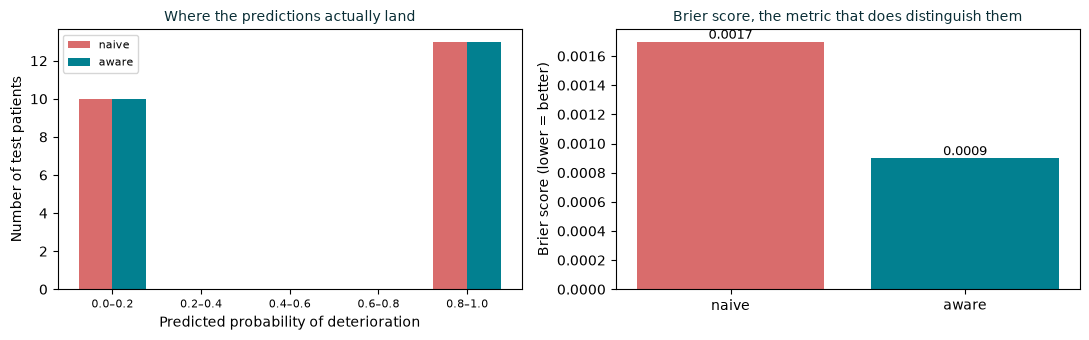

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

ax = axes[0]
bin_edges = np.linspace(0, 1, 6)
counts_naive, _ = np.histogram(proba_naive, bins=bin_edges)
counts_aware, _ = np.histogram(proba, bins=bin_edges)
x = np.arange(len(counts_naive))
width = 0.38
ax.bar(x - width/2, counts_naive, width, color=CORAL, label="naive")
ax.bar(x + width/2, counts_aware, width, color=TEAL, label="aware")
ax.set_xticks(x)
ax.set_xticklabels([f"{bin_edges[i]:.1f}\u2013{bin_edges[i+1]:.1f}" for i in range(len(counts_naive))], fontsize=8)
ax.set_xlabel("Predicted probability of deterioration")
ax.set_ylabel("Number of test patients")
ax.set_title("Where the predictions actually land", fontsize=10, color=DARK)
ax.legend(fontsize=8)

ax = axes[1]
briers = [brier_score_loss(yte_naive, proba_naive), brier_score_loss(yte, proba)]
ax.bar(["naive", "aware"], briers, color=[CORAL, TEAL])
ax.set_ylabel("Brier score (lower = better)")
ax.set_title("Brier score, the metric that does distinguish them", fontsize=10, color=DARK)
for i, b in enumerate(briers):
    ax.text(i, b, f"{b:.4f}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
plt.show()

Left panel is the honest version of "there's no calibration story here". Every single test patient, from both models, lands in the bottom or top bin, nothing in between. That's not a limitation of the chart, but it is what the underlying corpus actually looks like, cleanly separable, which is exactly why a calibration curve earlier would have shown you two flat, uninformative lines rather than a real finding.

Right panel is where the two models actually part ways. Same test patients, same rough placement, and the aware model is still measurably more honest about its own confidence. Small effect, real effect, worth taking seriously precisely because it shows up even in data this forgiving.

### What a threshold costs

AUROC and Brier both summarise a model across every possible threshold. Nobody deploys a model that way. Deployment means choosing one number above which you act, and that choice is where the clinical cost actually lands.

The two errors are not symmetric. A false alarm costs a clinician's attention. A missed deterioration costs considerably more than that. Worth seeing what the threshold does to each.

In [82]:
from sklearn.metrics import recall_score, precision_score

rows = []
for th in [0.1, 0.25, 0.5, 0.75, 0.9]:
    pred = (proba >= th).astype(int)
    missed = int(((yte == 1) & (pred == 0)).sum())
    false_alarms = int(((yte == 0) & (pred == 1)).sum())
    rows.append({
        "threshold": th,
        "recall": recall_score(yte, pred, zero_division=0),
        "precision": precision_score(yte, pred, zero_division=0),
        "missed deteriorations": missed,
        "false alarms": false_alarms,
    })

thresholds = pd.DataFrame(rows).set_index("threshold")
print(thresholds.round(3).to_string())
print()
print("On this corpus the columns barely move, because the classes do not overlap.")
print("On a corpus where they do, this table is the argument between a clinician")
print("and a data scientist, and it is not settled by AUROC.")

           recall  precision  missed deteriorations  false alarms
threshold                                                        
0.10          1.0        1.0                      0             0
0.25          1.0        1.0                      0             0
0.50          1.0        1.0                      0             0
0.75          1.0        1.0                      0             0
0.90          1.0        1.0                      0             0

On this corpus the columns barely move, because the classes do not overlap.
On a corpus where they do, this table is the argument between a clinician
and a data scientist, and it is not settled by AUROC.


Here the table is flat, for the reason the separability chart already gave you. That flatness is worth showing rather than skipping, because it makes the point that this corpus cannot support a threshold conversation, and a real one can.

So the honest summary of evaluation in this tutorial is four metrics doing four different jobs. AUROC ranks and tells you almost nothing here. Brier scores confidence and separated the naive model from the aware one when AUROC could not. The ablation earlier used Brier again to show that three of four modalities carry little. And a threshold table converts all of it into the two numbers a clinician actually argues about, missed events and false alarms.

None of those four is the evaluation. The set of them is.

## Where this maps to regulation

The EU AI Act treats clinical prediction systems as high-risk, and its core requirements aren't abstract, they map directly onto specific artifacts you've already built across this tutorial, not onto anything new.

| AI Act requirement | What you already built |
|---|---|
| Traceability of training data and decisions | Block 1's schema-validated document object, with per-stream provenance tagging exactly where each fact came from |
| Record-keeping and audit trails | The amendment mechanism: a correction never overwrites history, it's appended, timestamped, and `document_schema.json` rejects one with no pointer back to what it corrects |
| Meaningful human oversight | This block's audit tool: a specific, checkable flag for when a model's confidence rests on evidence a human should look at again |
| Accuracy, robustness, and subgroup fairness | Block 2's subgroup recall breakdown, plus the Brier score comparison above, evaluation that doesn't stop at one aggregate number |
| Risk management across the system lifecycle | The whole naive-model-caught-cheating-then-fixed-architecturally arc of Block 2, done once, reusable as a pattern |

None of this makes a system compliant on its own, that's a legal determination, not a technical one. But "traceability" and "meaningful human oversight" stop being compliance checkboxes the moment you've built the specific mechanisms that make them concretely true, rather than asserted.

## The same code, a different domain

Every argument in this tutorial has been made using ICU data, on purpose, because high-stakes and concrete beats abstract. But the claim was never "hospitals are special." The claim was that temporal entanglement is a document engineering problem, one that shows up anywhere a document system captures an evolving real-world process under uncertainty. `generate_education_domain.py` builds a second, small, completely unrelated corpus: students in an online course, not patients in an ICU. Daily engagement instead of vital signs. Quiz scores, graded days later, instead of labs. Counselor notes, written well after a student actually started struggling, instead of clinical notes. An uncertain "started struggling" window instead of an uncertain deterioration onset.

Watch what doesn't change: `alignment.py`. Not a wrapper around it, not a re-skinned copy, the literal same import you've used since Block 2.

In [83]:
engagement = pd.read_csv(f"{DATA_DIR}/education_engagement.csv", parse_dates=["timestamp"])
assessments = pd.read_csv(f"{DATA_DIR}/education_assessments.csv", parse_dates=["assess_time", "result_time"])
edu_notes = pd.read_csv(f"{DATA_DIR}/education_notes.csv", parse_dates=["event_time", "storetime"])
edu_labels = pd.read_csv(f"{DATA_DIR}/education_labels.csv",
                          parse_dates=["true_onset_time", "possible_window_start", "possible_window_end"])

In [84]:
display(engagement.head(3))
display(assessments.head(3))
display(edu_notes.head(3))
display(edu_labels.head(3))

,student_id,timestamp,minutes_active
0,STU001,2026-02-02 18:00:00,59.1
1,STU001,2026-02-03 18:00:00,43.8
2,STU001,2026-02-04 19:00:00,52.4


,student_id,assess_time,result_time,score
0,STU001,2026-02-06 12:00:00,2026-02-07 17:08:00,91.7
1,STU001,2026-02-11 13:00:00,2026-02-14 02:09:00,83.0
2,STU001,2026-02-18 14:00:00,2026-02-21 20:14:00,75.8


,student_id,note_id,note_type,event_time,storetime,text
0,STU001,STU001-N1,routine_checkin,2026-02-12 00:00:00,2026-02-12 05:03:00,Routine check-in. Student engagement and perfo...
1,STU001,STU001-N2,concern_flagged,2026-03-17 00:00:00,2026-03-28 07:45:00,Noticed declining engagement and quiz performa...
2,STU001,STU001-N3,intervention,2026-03-30 05:16:00,2026-03-30 06:37:00,Met with student to discuss course difficultie...


,student_id,needs_intervention,true_onset_time,possible_window_start,possible_window_end
0,STU001,1,2026-03-17,2026-03-15,2026-03-22
1,STU002,1,2026-03-16,2026-03-14,2026-03-21
2,STU003,0,NaT,NaT,NaT


In [85]:
student_id = "STU001"
student_eng = engagement[engagement.student_id == student_id]
lrow = edu_labels.set_index("student_id").loc[student_id]
prediction_time = lrow.possible_window_start + pd.Timedelta(days=1)

print(f"Student {student_id}, needs_intervention = {lrow.needs_intervention}")
print(f"  {len(student_eng)} engagement records over "
      f"{(student_eng.timestamp.max() - student_eng.timestamp.min()).days} days")
print(f"  Possible onset window: {lrow.possible_window_start.date()} to {lrow.possible_window_end.date()}, "
      f"{(lrow.possible_window_end - lrow.possible_window_start).days} days wide")
print(f"  Prediction time: {prediction_time.date()}")

flag = edu_notes[(edu_notes.student_id == student_id) & (edu_notes.note_type == "concern_flagged")]
if len(flag):
    f = flag.iloc[0]
    lag_days = (f.storetime - f.event_time).total_seconds() / 86400
    print(f"  The counsellor's concern note was charted {lag_days:.1f} days after the moment it describes.")
    print(f"  That is the same documentation lag from Block 1, measured in days instead of hours.")

Student STU001, needs_intervention = 1
  50 engagement records over 66 days
  Possible onset window: 2026-03-15 to 2026-03-22, 7 days wide
  Prediction time: 2026-03-16
  The counsellor's concern note was charted 11.3 days after the moment it describes.
  That is the same documentation lag from Block 1, measured in days instead of hours.


/var/folders/wt/05f8y2kx0w79j50x0tz166tr0000gn/T/ipykernel_9067/3261288463.py:4: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  prediction_time = lrow.possible_window_start + pd.Timedelta(days=1)


In [86]:
# the exact same functions, completely unmodified, imported from alignment.py
window = al.naive_window(student_eng, "timestamp", prediction_time, lookback_hours=336)
last, slope, n = al.event_centered_trend(student_eng, "timestamp", "minutes_active", prediction_time, lookback_hours=336)
n_obs, completeness = al.missingness_features(student_eng, "timestamp", prediction_time, lookback_hours=336, expected_per_day=1)

print(f"al.naive_window()          -> {len(window)} engagement readings in a 14-day lookback")
print(f"al.event_centered_trend()  -> last={last:.1f} min/day, slope={slope:+.3f} min/day per hour, n={n}")
print(f"al.missingness_features()  -> {n_obs} logins observed, completeness ratio={completeness:.2f}")
print()
print("al.soft_event_label() across the onset window:")
for offset_days in [-3, -1, 0, 2, 4, 7]:
    t = lrow.possible_window_start + pd.Timedelta(days=offset_days)
    soft = al.soft_event_label(t, lrow.possible_window_start, lrow.possible_window_end)
    print(f"  day {offset_days:+d} relative to window start: soft label = {soft:.2f}")

al.naive_window()          -> 11 engagement readings in a 14-day lookback
al.event_centered_trend()  -> last=39.7 min/day, slope=-0.034 min/day per hour, n=11
al.missingness_features()  -> 11 logins observed, completeness ratio=0.79

al.soft_event_label() across the onset window:
  day -3 relative to window start: soft label = 0.00
  day -1 relative to window start: soft label = 0.00
  day +0 relative to window start: soft label = 0.00
  day +2 relative to window start: soft label = 0.29
  day +4 relative to window start: soft label = 0.57
  day +7 relative to window start: soft label = 1.00


/var/folders/wt/05f8y2kx0w79j50x0tz166tr0000gn/T/ipykernel_9067/3359443293.py:12: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  t = lrow.possible_window_start + pd.Timedelta(days=offset_days)


There are no modifications from the ICU temporal entanglement story, even when applied one new domain. `naive_window` does not know or care whether it is windowing heart rate or login minutes. `soft_event_label` does not know whether the uncertain event is a deterioration or a student falling behind. That's not a coincidence, it's what "the framework generalizes" is supposed to mean when you actually check it rather than just claim it in an abstract.

Now the visual version, same grammar as every timeline plot in this tutorial: open circle for when something happened, filled marker for when it was recorded, the gap between them drawn to scale.

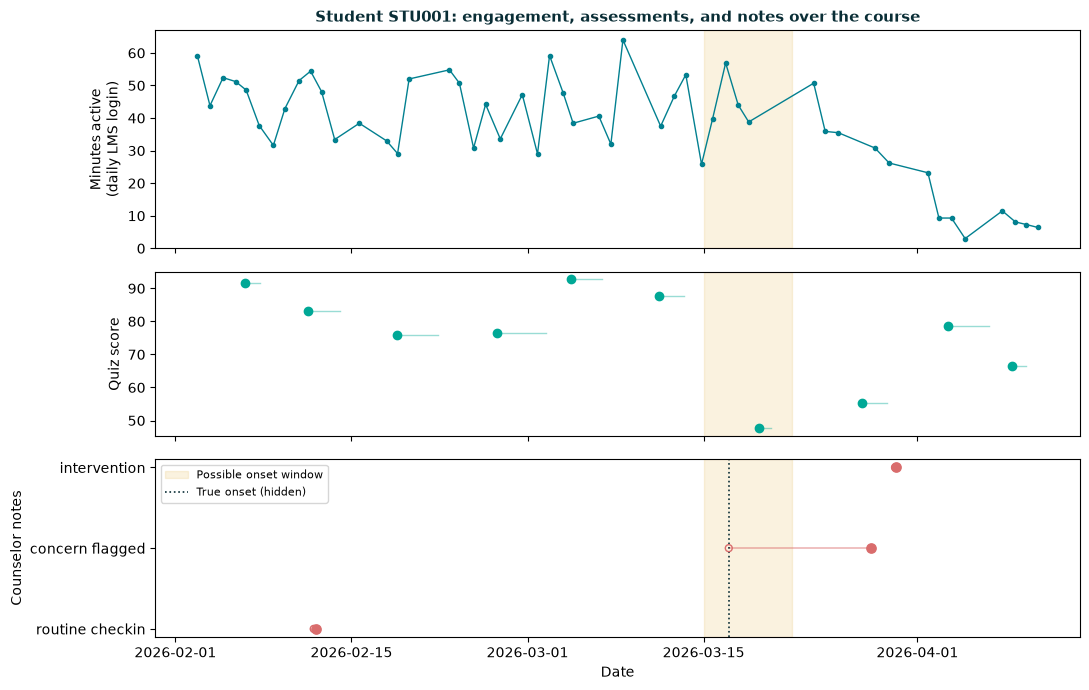


The 'concern flagged' note, the classroom's version of a clinical note, was charted 11.3 days after this student actually started struggling. Same problem, same shape, zero shared vocabulary with the word 'patient'.


In [87]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True, gridspec_kw=dict(height_ratios=[1.6, 1.2, 1.3]))

sa = assessments[assessments.student_id == student_id]
sn = edu_notes[edu_notes.student_id == student_id]

ax = axes[0]
ax.plot(student_eng.timestamp, student_eng.minutes_active, "o-", color=TEAL, markersize=3, linewidth=1)
ax.axvspan(lrow.possible_window_start, lrow.possible_window_end, color=AMBER, alpha=0.15)
ax.set_ylabel("Minutes active\n(daily LMS login)")
ax.set_title(f"Student {student_id}: engagement, assessments, and notes over the course",
             fontsize=11, color=DARK, fontweight="bold")

ax = axes[1]
ax.plot(sa.assess_time, sa.score, "o", color=SEAFOAM, markersize=6)
for _, r in sa.iterrows():
    ax.plot([r.assess_time, r.result_time], [r.score, r.score], color=SEAFOAM, alpha=0.4, linewidth=1)
ax.axvspan(lrow.possible_window_start, lrow.possible_window_end, color=AMBER, alpha=0.15)
ax.set_ylabel("Quiz score")

ax = axes[2]
y_pos = {t: i for i, t in enumerate(sn.note_type.unique())}
for _, r in sn.iterrows():
    yv = y_pos[r.note_type]
    ax.plot([r.event_time, r.storetime], [yv, yv], color=CORAL, alpha=0.5, linewidth=1.2)
    ax.scatter(r.event_time, yv, color=CORAL, s=25, marker="o", facecolors="none", zorder=3)
    ax.scatter(r.storetime, yv, color=CORAL, s=45, marker="o", zorder=3)
ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels([t.replace("_", " ") for t in y_pos.keys()])
ax.axvspan(lrow.possible_window_start, lrow.possible_window_end, color=AMBER, alpha=0.15, label="Possible onset window")
ax.axvline(lrow.true_onset_time, color=DARK, linestyle=":", linewidth=1.2, label="True onset (hidden)")
ax.set_ylabel("Counselor notes")
ax.set_xlabel("Date")
ax.legend(fontsize=8, loc="upper left")

fig.tight_layout()
plt.show()

lag_h = (sn[sn.note_type=="concern_flagged"].storetime.iloc[0] - lrow.true_onset_time).total_seconds() / 3600
print(f"\nThe 'concern flagged' note, the classroom's version of a clinical note, was charted "
      f"{lag_h/24:.1f} days after this student actually started struggling. Same problem, same shape, zero shared vocabulary with the word 'patient'.")

That's the argument this whole tutorial has been building toward, made visible instead of asserted: engagement drops right around the possible onset window, quiz scores follow within days, and the note that's supposed to catch it doesn't get written until well after the fact, the exact documentation-lag shape from Block 1's very first timeline plot, now playing out in a classroom `alignment.py` has never seen before this cell. Legal proceedings, financial audit trails, anywhere a document system captures an evolving process under timing uncertainty, this is the same problem wearing a different vocabulary.

### The same shape, measured

One student's timeline is an anecdote. The claim was that the same *shape* appears in both domains, so let me measure it in both and put the numbers side by side.

The fair comparison is like for like: the note that first flags a problem. In the ICU that is an `event_clinician` note. In the classroom it is a counsellor's `concern_flagged` note.

In [89]:
icu_ev = notes[notes.note_type == "event_clinician"]
icu_lag = (icu_ev.storetime - icu_ev.event_charttime).dt.total_seconds() / 3600

edu_ev = edu_notes[edu_notes.note_type == "concern_flagged"]
edu_lag = (edu_ev.storetime - edu_ev.event_time).dt.total_seconds() / 3600

ICU_STAY_H = 72       # a typical stay in this corpus
COURSE_H = 10 * 7 * 24  # the education corpus runs ten weeks

print("The note that first flags a problem, in each domain:")
print(f"  ICU, event_clinician      n ={len(icu_lag):3d}   median lag {icu_lag.median():6.1f} h  ({icu_lag.median()/24:.1f} days)")
print(f"  Course, concern_flagged   n ={len(edu_lag):3d}   median lag {edu_lag.median():6.1f} h  ({edu_lag.median()/24:.1f} days)")
print()
print("Absolute times are nothing alike. As a fraction of the process each sits inside:")
print(f"  ICU:    {icu_lag.median()/ICU_STAY_H:.0%} of a stay")
print(f"  Course: {edu_lag.median()/COURSE_H:.0%} of a course")

The note that first flags a problem, in each domain:
  ICU, event_clinician      n = 35   median lag    6.8 h  (0.3 days)
  Course, concern_flagged   n =  8   median lag  171.9 h  (7.2 days)

Absolute times are nothing alike. As a fraction of the process each sits inside:
  ICU:    9% of a stay
  Course: 10% of a course


Seven hours against seven days. In absolute terms these two domains have nothing to say to each other.

As a proportion of the process being documented, one is 9% and the other 10%.

I want to be careful about how much weight that carries. I generated both corpora, so this is not evidence about the world, and with eight counsellor notes it would not be evidence even if I had not. What it does show is that the quantity worth comparing across domains is lag *relative to the process*, not lag in hours, and that is a modelling decision rather than a finding. A fixed 48-hour lookback window is a sensible default in an ICU and meaningless in a ten-week course. The window has to scale with the process, which is exactly why `lookback_hours` is an argument to `naive_window` rather than a constant inside it.

### Every student, not just the one picked

The last thing worth checking is that STU001 was not cherry-picked. Run the alignment functions across every student in the corpus who needs intervention.

In [90]:
rows = []
for r in edu_labels.itertuples():
    if pd.isna(r.possible_window_start):
        continue
    se = engagement[engagement.student_id == r.student_id]
    p = r.possible_window_start + pd.Timedelta(days=1)
    last, slope, n_obs = al.event_centered_trend(se, "timestamp", "minutes_active", p, lookback_hours=336)
    _, completeness = al.missingness_features(se, "timestamp", p, 336, expected_per_day=1)
    rows.append(dict(student=r.student_id, engagement_last=round(last, 1),
                     slope=round(slope, 3), completeness=round(completeness, 2),
                     readings=n_obs))

corpus = pd.DataFrame(rows)
print(f"alignment.py ran on all {len(corpus)} students needing intervention, no failures, no special cases:")
print(corpus.to_string(index=False))

alignment.py ran on all 8 students needing intervention, no failures, no special cases:
student  engagement_last  slope  completeness  readings
 STU001             39.7 -0.034          0.79        11
 STU002             51.8 -0.002          0.86        12
 STU008             55.7  0.015          0.93        13
 STU011             39.3 -0.043          1.00        14
 STU012             45.0 -0.005          1.00        14
 STU014             36.4 -0.005          0.93        13
 STU018             46.3  0.023          1.00        14
 STU019             52.8 -0.017          1.00        14


/var/folders/wt/05f8y2kx0w79j50x0tz166tr0000gn/T/ipykernel_9067/1590203631.py:6: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  p = r.possible_window_start + pd.Timedelta(days=1)
/var/folders/wt/05f8y2kx0w79j50x0tz166tr0000gn/T/ipykernel_9067/1590203631.py:6: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  p = r.possible_window_start + pd.Timedelta(days=1)
/var/folders/wt/05f8y2kx0w79j50x0tz166tr0000gn/T/ipykernel_9067/1590203631.py:6: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  p = r.poss

Every student returns a value. No errors, no missing-data special cases, no domain-specific branches anywhere in `alignment.py`.

The slopes are worth a second look though, because several are flat or slightly positive at this prediction point even for students who genuinely do fall behind. That is not a bug. It is the same uncertain-onset problem from Block 2, arriving in a new domain: one day past the start of the possible window, some of these students have not measurably started declining yet. The window is uncertain precisely because the event does not happen at a single moment, and a model asked to predict at that instant is working with genuinely ambiguous evidence.

Which is the point I would rather end on than a tidy result. The framework transferred. So did the hard part.

## Your turn

- **Run the audit across all four modalities.** It currently runs on `aware_df`. Point `time_located_report()` at `mm_df` and `pipe_mm` instead, extend `FEATURE_SOURCE` with entries for the `ecg_`, `echo_`, and `text_` features, and use the evidence ages `modality_report()` already computes. The diagnostic studies are the oldest evidence in most charts, so I would expect more flags, not fewer.
- Lower `staleness_threshold` in `audit_temporal_consistency()` and see how many predictions get flagged. Raise it and watch them disappear. There is a real design decision hiding in that one number, and the answer should come from clinicians rather than from whatever I happened to type as a default.
- Change which modality a feature belongs to in the `MODALITY` dictionary. Move `vitals_completeness` out of the biosignal group and into its own "data quality" modality, then re-run the cross-modal chart. Grouping is an editorial choice, and it changes what the figure appears to say.
- Add a fifth modality. The echo reports carry `wall_motion_abnormality` and `valve_regurgitation`, both unused here. Does the picture change, and does the extra evidence arrive early enough to be worth having?
- Pick a patient with an amendment from Block 1 and re-run the multimodal section. The corrected drug now genuinely reaches the model through `text_has_diuretic`, which it never did before this block. Does the correction move the prediction?
- In the education corpus, change `student_id` to any of the eight struggling students. The decline timing differs by student on purpose, because real students do not fall behind on a schedule.
- The largest one, if you have the appetite. Financial audit trails appear in this tutorial's abstract and I never built them. What is the continuous signal there, and what is the delayed narrative? My claim is that `alignment.py` would not need to change. Test it.

## What you built

- Exact per-prediction attribution, the literal decomposition of what the model computed, checked against the model's own output rather than assumed
- A model that reads all four evidence streams in the record, biosignal, tabular, diagnostic studies, and the content of the notes, so that an explanation can cover the whole chart instead of the convenient half of it
- Cross-modal attribution fused with evidence age, the figure this tutorial has been pointing at since Block 0
- A reusable temporal-inconsistency audit tool, which found the same prediction I picked by eye and then proved across the held-out set that the pick was not luck
- An honest account of evaluation beyond AUROC, including the part where this corpus does not support the dramatic calibration story I would have preferred to tell
- A mapping from EU AI Act requirements to artefacts that already existed by the time we got there
- Proof, rather than a claim, that all four alignment functions run unchanged on a domain that has never heard of a patient

## Where the whole tutorial leaves you

Four blocks, one argument. Temporal entanglement is a document engineering problem first, and becomes a machine learning problem only once the representation has already gone wrong.

Block 0 introduced the corpus and the formats underneath it. Block 1 narrowed to a single chart, made you compute documentation lag by hand, and showed you a correction that changed what the record said halfway through a stay. Block 2 caught a model exploiting the gap none of that had closed yet, and then closed it. This block showed you how to see what the fixed model actually uses, across every stream rather than the easy ones, how to audit that automatically, how to explain it to a regulator, and that none of it was ever specific to an ICU.

Take `alignment.py`. Take the schema. Take the audit tool. They do not know what domain they are in, and you no longer have to treat the next one as a special case.